# Exploration 05 — new formulas, error structure, and what the models learned (X2)

> **Exploratory** (development work, kept separate from the test-set comparison). **Inputs:** Z and R only for every model. Mulliken charges (a DFT
> output) appear once, in section 4, only to *interpret* the trained charge network, never as an input. **Data:**
> training sets S_(s,N) and the development sets `dev` and `dev_unseen`. No test set is read.

**Part 5 of the classical analysis.** Uses the features (02), the preprocessing choices (03) and the models and
development-set predictions of notebook 04 (run 04 first). Questions:
1. **New formulas.** The brief asks whether a model works on formulas absent from training. The unseen-formula
   test set answers that in the test runs (`scripts/final_eval.py`, notebook `07_test_comparison`). Here, `dev_unseen` (26 whole formulas never in any training set)
   and formula-grouped CV inside the Track B training sets estimate it without touching the test set.
2. **Where do the errors come from?** By |μ| band, charged group, size and formula rarity.
3. **What do the tabular models use?** Permutation importance on the development set.
4. **What did the charge network learn?** Its per-atom charges against the DFT's Mulliken charges, and an
   end-to-end check that its predictions do not change when a molecule is rotated, moved or relabeled.

**Track A and Track B.** The classical models come in two tracks, which answer different questions:

| | **Track A**: the most accurate classical model | **Track B**: quantum-comparable classical models |
|---|---|---|
| **Question** | How accurate can a classical model get from Z and R? | Given exactly what a quantum model gets, does the quantum model do better? |
| **Training data** | Any size, from 100 molecules up to the full 99,198-molecule training pool | At most 1,000 molecules (N = 100, 300, 1,000), the sizes a quantum kernel can afford |
| **Inputs** | All 188 features computed from Z and R, or per-atom features (latent-charge network) | The quantum models' inputs: 10 PLS components of the 188 features, one per qubit (chosen in notebook 03), or composition only |
| **Models** | Ridge, RBF kernel ridge, XGBoost, the latent-charge network | Mean, ridge, RBF kernel ridge, random forest (and XGBoost in notebook 04) |
| **Preprocessing and tuning** | Chosen for accuracy: log-standard scaling, standardized target; CV or an inner validation split | Identical to the quantum models: Yeo-Johnson scaling, √\|μ\| target, the same 5-fold CV folds and grid sizes |

Every quantum result is reported against both: Track B is the like-for-like comparison, and Track A shows how far
classical methods go without those limits.

In [1]:
# Environment check: stops here, with setup instructions, unless this kernel is the project
# environment (README.md, "Setup"). Version differences from requirements.txt only warn.
try:
    from qm9dipole.provenance import check_environment
except ModuleNotFoundError as e:
    raise RuntimeError(
        "The qm9dipole package is not installed in this kernel's environment. Follow "
        "README.md (Setup), then select that environment as the notebook kernel."
    ) from e

print(check_environment())

environment OK: Python 3.12.14, 16 pinned packages checked, 0 differ; package and notebook are in the same checkout


In [2]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from qm9dipole import REPO_ROOT
from qm9dipole.analysis import error_by_group
from qm9dipole.data import PROCESSED_DIR, load_qm9_table
from qm9dipole.evaluate import group_kfold, learning_curve, scores
from qm9dipole.explore import (atom_feature_names, feature_sets, load_catalog, load_config, load_features,
                               load_preprocessing)
from qm9dipole.models import classical
from qm9dipole.plots import AXIS, INK_SECONDARY, MODEL_COLORS, MODEL_LABELS, MUTED, SEQUENTIAL, SERIES, SURFACE, use_style
from qm9dipole.provenance import RESULTS_DIR, save_result
from qm9dipole.splits import load_splits
from qm9dipole.provenance import figure_file, results_file

use_style()
FIG_DIR = REPO_ROOT / "figures"
CFG = load_config()
features = load_features()
catalog = load_catalog()
SETS = feature_sets(catalog)
PRE = load_preprocessing()
SC_A, SC_B, TG_A, TG_B = PRE["scaling"]["track_a"], PRE["scaling"]["track_b"], PRE["target"]["track_a"], PRE["target"]["track_b"]
RED = (PRE["reduction"]["method"], int(PRE["reduction"]["k"]))
splits = load_splits()
y = features["mu"]
FULL = splits.sizes[-1]
track_a = pd.read_csv(results_file("explore04_track_a.csv"))
track_b = pd.read_csv(results_file("explore04_track_b.csv"))
selection = json.loads((results_file("explore04_charge_selection.meta.json")).read_text())
preds = pd.read_parquet(PROCESSED_DIR / "explore04_dev_predictions.parquet")
groups = features.loc[:, [c for c in ("atoms_N4", "n_carboxylate", "zwitterion") if c in features]]
print(f"chosen charge network: {selection['chosen']}; Track A rows {len(track_a)}, Track B rows {len(track_b)}")

chosen charge network: mp3; Track A rows 240, Track B rows 324


## 1. Familiar vs new formulas

### 1a. Track A: `dev` vs `dev_unseen` at every N
`dev` molecules have formulas that are in the training pool; `dev_unseen` molecules belong to 26 formulas that never
appear in any training set. The gap is the cost of a new formula, mixed with any difference between the two sets'
chemistry (26 formulas is a small sample of chemistry, so read the gap as indicative).

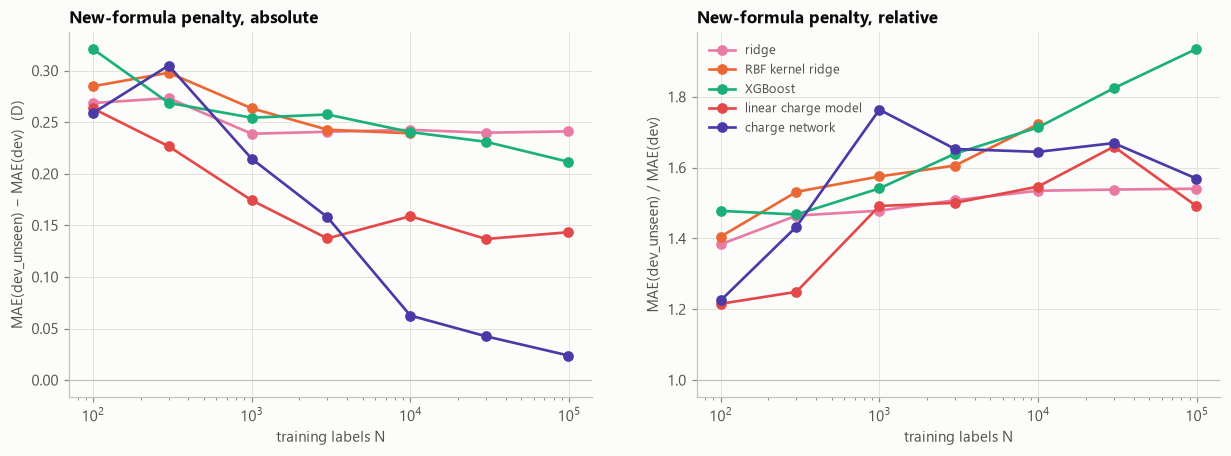

n_train,100,300,1000,3000,10000,30000,99198
model,,,,,,,
RBF kernel ridge,+0.285,+0.298,+0.264,+0.243,+0.239,+nan,+nan
XGBoost,+0.321,+0.269,+0.254,+0.257,+0.240,+0.231,+0.212
charge network,+0.259,+0.305,+0.215,+0.158,+0.063,+0.042,+0.024
linear charge model,+0.263,+0.227,+0.174,+0.137,+0.159,+0.137,+0.143
ridge,+0.269,+0.273,+0.239,+0.241,+0.243,+0.240,+0.241


In [3]:
summ = track_a.groupby(["model", "n_train", "eval_set"])["mae_D"].mean().unstack("eval_set")
summ["new-formula penalty (D)"] = summ["dev_unseen"] - summ["dev"]
summ["ratio"] = summ["dev_unseen"] / summ["dev"]
models = [m for m in ("ridge", "rbf_krr", "xgb", "charge_linear", "charge_net") if m in summ.index.get_level_values(0)]
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13.5, 4.3))
for m in models:
    s = summ.loc[m]
    ax0.plot(s.index, s["new-formula penalty (D)"], color=MODEL_COLORS[m], marker="o", label=MODEL_LABELS[m])
    ax1.plot(s.index, s["ratio"], color=MODEL_COLORS[m], marker="o", label=MODEL_LABELS[m])
for ax in (ax0, ax1):
    ax.set_xscale("log")
    ax.set_xlabel("training labels N")
ax0.axhline(0, color=AXIS, linewidth=0.8)
ax1.axhline(1, color=AXIS, linewidth=0.8)
ax0.set(ylabel="MAE(dev_unseen) − MAE(dev)  (D)", title="New-formula penalty, absolute")
ax1.set(ylabel="MAE(dev_unseen) / MAE(dev)", title="New-formula penalty, relative")
ax1.legend(fontsize=8.5)
fig.savefig(figure_file("explore05_new_formula_gap.png"))
plt.show()
display(summ.loc[models].reset_index().assign(model=lambda d: d["model"].map(MODEL_LABELS))
        .pivot(index="model", columns="n_train", values="new-formula penalty (D)")
        .style.format("{:+.3f}").set_caption("new-formula penalty MAE(dev_unseen) − MAE(dev), D, mean over seeds"))

### 1b. Track B: formula-grouped CV inside S_(s,1000)
The X1 check, for the quantum-comparable models: the same training sets, models and preprocessing as notebook 04,
but with `GroupKFold(5)` by formula, so no validation formula is in that fold's training part. Compared with the
random-fold CV MAE from notebook 04.

In [4]:
N = max(splits.track_b_sizes)
formula = features["formula"]
train_n = {s: {N: by_n[N]} for s, by_n in splits.train.items()}
RED_NAME = f"{RED[0]}{RED[1]}"
frames = {"all_legal": features[SETS["all_legal"]], RED_NAME: features[SETS["all_legal"]]}

def make_specs(seed, fname):
    reduction = RED if fname == RED_NAME else None
    return {m: classical.build(m, seed, scaling=SC_B, target=TG_B, reduction=reduction, n_features=len(SETS["all_legal"]))
            for m in ("ridge", "rbf_krr", "xgb")}

grouped, _ = learning_curve(make_specs, frames, y, train_n, make_folds=lambda ids, seed: group_kfold(formula.loc[ids].to_numpy(), seed),
                            eval_set="cv_by_formula", progress=False)
_ = save_result(grouped, "explore05_cv_by_formula", n_train=N, label="exploratory; Z, R only; formula-grouped CV inside S_(s,1000)")
random_cv = track_b[(track_b["n_train"] == N) & (track_b["eval_set"] == "dev")].groupby(["features", "model"])["cv_mae_D"].mean()
gap = grouped.groupby(["features", "model"])["mae_D"].mean().rename("formula-grouped CV").to_frame()
gap["random-fold CV"] = random_cv.reindex(gap.index)
gap["new-formula penalty (D)"] = gap["formula-grouped CV"] - gap["random-fold CV"]
display(gap.reset_index().assign(model=lambda d: d["model"].map(MODEL_LABELS)).set_index(["features", "model"])
        .style.format("{:.3f}").set_caption(f"CV MAE (D) at N = {N}, mean over 3 seeds"))

## 2. Where do the errors come from?

The best Track A model at the full pool (seed 0) against the best tabular model (XGBoost) on the same development
molecules: parity plots, then errors broken down by the true |μ|, by charged group read from geometry, by size, and
by how common the molecule's formula is in the training pool.

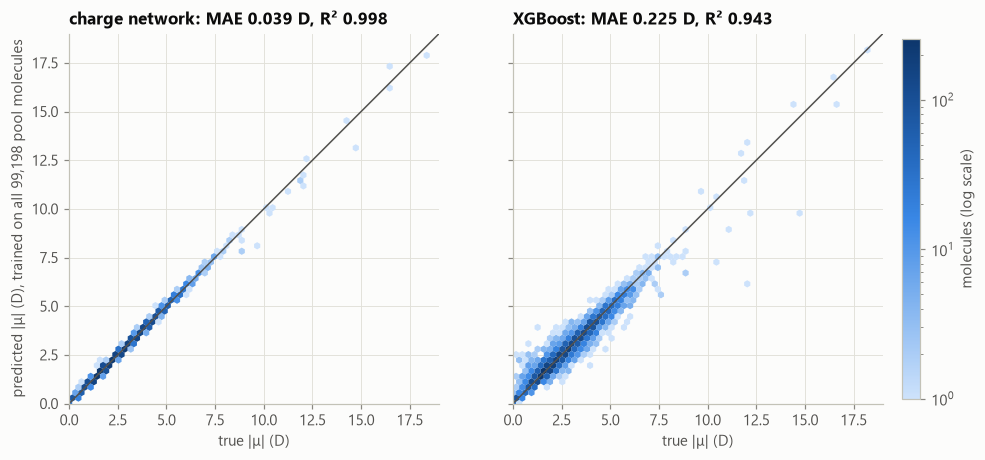

In [5]:
dev_full = track_a[(track_a["n_train"] == FULL) & (track_a["eval_set"] == "dev")].groupby("model")["mae_D"].mean()
best = dev_full.drop(index="mean").idxmin()
pair = [best, "xgb"] if best != "xgb" else ["xgb", "ridge"]
P = preds[(preds["track"] == "A") & (preds["seed"] == 0) & (preds["n_train"] == FULL)]
p = {m: P[(P["model"] == m) & (P["eval_set"] == "dev")].set_index("id")["pred_D"] for m in pair}
yd = y.loc[splits.dev]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), sharey=True)
lim = (0, float(np.ceil(max(yd.max(), max(v.max() for v in p.values())))))
for ax, m in zip(axes, pair):
    hb = ax.hexbin(yd, p[m].loc[yd.index], gridsize=60, bins="log", cmap=SEQUENTIAL, mincnt=1, linewidths=0, extent=(*lim, *lim))
    ax.plot(lim, lim, color=INK_SECONDARY, linewidth=1)
    s = scores(yd, p[m].loc[yd.index])
    ax.set(xlim=lim, ylim=lim, xlabel="true |μ| (D)", aspect="equal",
           title=f"{MODEL_LABELS[m]}: MAE {s['mae_D']:.3f} D, R² {s['r2']:.3f}")
axes[0].set_ylabel(f"predicted |μ| (D), trained on all {FULL:,} pool molecules")
fig.colorbar(hb, ax=axes, label="molecules (log scale)", shrink=0.85, pad=0.02)
fig.savefig(figure_file("explore05_parity.png"))
plt.show()

def breakdown(by, name):
    return pd.concat({MODEL_LABELS[m]: error_by_group(yd, p[m].loc[yd.index], by).set_index("group") for m in pair}, axis=1).rename_axis(name)

bands = pd.cut(yd, [0, 1, 2, 3, 4, 6, 9, np.inf], right=False, labels=["0–1", "1–2", "2–3", "3–4", "4–6", "6–9", "≥ 9"])
g = features.loc[yd.index]
charged = pd.Series(np.select([g["zwitterion"] > 0, g["n_carboxylate"] > 0, g["atoms_N4"] > 0],
                              ["zwitterion", "carboxylate only", "ammonium only"], "neither"), index=yd.index)
fsize = formula.loc[splits.pool].value_counts()
rarity = pd.cut(formula.loc[yd.index].map(fsize), [0, 10, 100, 1000, np.inf], labels=["< 10", "10–100", "100–1000", "≥ 1000"])
for by, name in [(bands, "true |μ| (D)"), (charged, "charged groups"), (features.loc[yd.index, "n_heavy"], "heavy atoms"),
                 (rarity, "pool molecules with this formula")]:
    t = breakdown(by, name)
    display(t.style.format("{:.3f}", subset=[c for c in t.columns if c[1] != "n"]).set_caption(f"dev errors by {name} (D)"))

## 3. What do the tabular models use?

Permutation importance on the development set: XGBoost refit on S_(0,10000) with the hyperparameters notebook 04
chose there; then each feature column of the development set is shuffled in turn and the rise in MAE recorded (3
repeats). No refitting, so importances describe this fitted model on molecules it has not seen. Correlated features
share credit (shuffling one leaves its correlates intact), so groups of similar radial-distribution bins can look
individually weak.

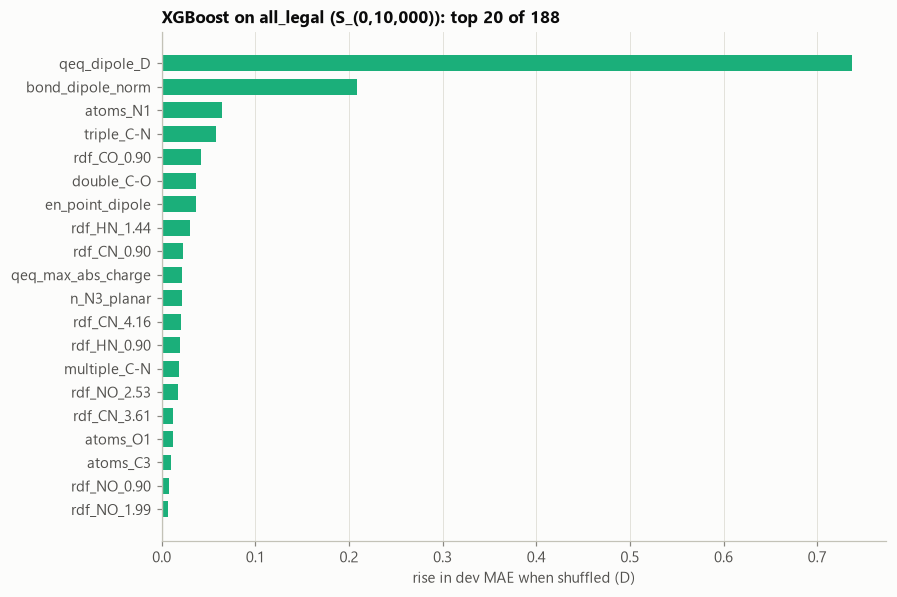

dev MAE of this model: 0.335 D


In [6]:
from xgboost import XGBRegressor
from qm9dipole.preprocess import target_transformer

NI = 10000
row = track_a[(track_a["model"] == "xgb") & (track_a["seed"] == 0) & (track_a["n_train"] == NI)].iloc[0]
d = json.loads(row["details"])
ids = splits.train[0][NI]
XA = features[SETS["all_legal"]]
tt = target_transformer(TG_A).fit(y.loc[ids].to_numpy()[:, None])
xgb = XGBRegressor(n_estimators=d["n_trees"], tree_method="hist", random_state=0, n_jobs=-1, **d["params"])
xgb.fit(XA.loc[ids].to_numpy(np.float32), tt.transform(y.loc[ids].to_numpy()[:, None]).ravel())
Xd = XA.loc[splits.dev].to_numpy(np.float32)

def predict(X):
    return np.clip(tt.inverse_transform(xgb.predict(X)[:, None]).ravel(), 0, None)

base = np.abs(predict(Xd) - yd.to_numpy()).mean()
rng = np.random.default_rng(0)
rise = np.zeros(Xd.shape[1])
for j in range(Xd.shape[1]):
    for _ in range(3):
        Xp = Xd.copy()
        Xp[:, j] = rng.permutation(Xp[:, j])
        rise[j] += (np.abs(predict(Xp) - yd.to_numpy()).mean() - base) / 3
imp = pd.Series(rise, index=SETS["all_legal"]).sort_values()
fig, ax = plt.subplots(figsize=(8.5, 6))
show = imp.tail(20)
ax.barh(show.index, show.values, color=MODEL_COLORS["xgb"], height=0.68)
ax.axvline(0, color=AXIS, linewidth=0.8)
ax.set(xlabel="rise in dev MAE when shuffled (D)", title=f"XGBoost on all_legal (S_(0,{NI:,})): top 20 of {len(imp)}")
ax.grid(axis="y", visible=False)
fig.savefig(figure_file("explore05_permutation_importance.png"))
plt.show()
_ = save_result(imp.rename("mae_rise_D").rename_axis("feature").reset_index(), "explore05_permutation_importance",
                model="xgb", seed=0, n_train=NI, n_repeats=3, base_dev_mae_D=float(base),
                label="exploratory; Z, R only; permutation importance on the development set")
print(f"dev MAE of this model: {base:.3f} D")

## 4. Inside the charge network

The chosen network is retrained on S_(0,10000) (same settings and seed as notebook 04) so it can be inspected.

**4a. Learned charges vs Mulliken charges (exploration only).** The network was trained on |μ| alone: it never saw a
charge. If its per-atom charges resemble the DFT's Mulliken charges, it has rediscovered physical charge transfer from
dipole magnitudes. Mulliken charges are used here only to describe the trained model. The comparison has two caveats:
the overall sign of the learned charges is arbitrary (a global flip leaves |μ| unchanged), so it is fixed by the
correlation's sign; and the network also has bond-directed atomic dipoles, so its charges need not carry the whole
dipole.

**4b. End-to-end invariance.** 300 development molecules are rotated, translated and relabeled; their per-atom
features are recomputed from the moved coordinates, and the trained network predicts again. A physically sensible
|μ| predictor must not change (a physical requirement of the brief). The negative control is ridge on raw, zero-padded coordinates.

retrained mp3 on S_(0,10,000) in 19.8 min; dev MAE 0.094 D


,n,Pearson r
atoms,,
all,89720,0.651
H,45669,0.605
C,32006,0.220
N,4923,0.079
O,6996,0.246
F,126,0.828


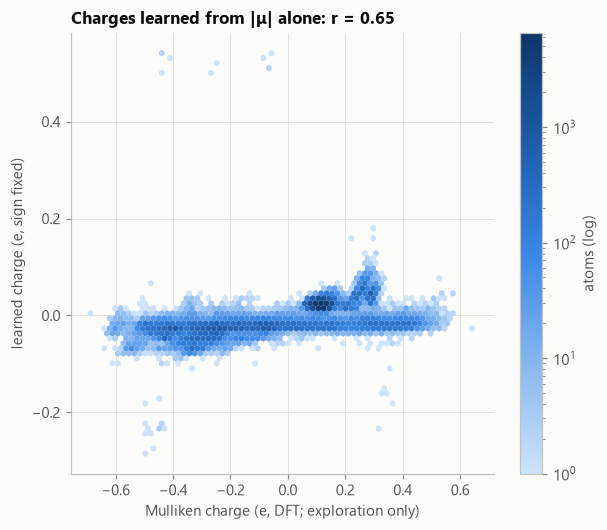

In [7]:
from qm9dipole.atoms import build_atom_data
from qm9dipole.explore import development_ids, load_atoms
from qm9dipole.models.charge import LatentChargeModel

table = load_qm9_table().set_index("id")
cand = CFG["charge_model"]["candidates"][selection["chosen"]]
params = {**CFG["charge_model"]["common"], **cand}
params["hidden"] = tuple(params["hidden"])
kept = atom_feature_names(catalog)
ids_tr = splits.train[0][NI]
start = time.perf_counter()
train_atoms = load_atoms(table.reset_index(), ids_tr, catalog)
net = LatentChargeModel(seed=0, **params).fit(train_atoms, y.loc[ids_tr].to_numpy())
dev_atoms = load_atoms(table.reset_index(), splits.dev, catalog)
print(f"retrained {selection['chosen']} on S_(0,{NI:,}) in {(time.perf_counter() - start) / 60:.1f} min; "
      f"dev MAE {np.abs(net.predict(dev_atoms) - yd.to_numpy()).mean():.3f} D")

q_net = net.charges(dev_atoms)
q_dft = np.concatenate(table.loc[splits.dev, "q"].to_numpy())
elem = np.array(["C", "H", "N", "O", "F"])[dev_atoms.element]
r = np.corrcoef(q_net, q_dft)[0, 1]
sign = np.sign(r)
q_net = sign * q_net
rows = [{"atoms": "all", "n": len(q_dft), "Pearson r": abs(r)}]
for e in ("H", "C", "N", "O", "F"):
    m = elem == e
    if m.sum() > 50:
        rows.append({"atoms": e, "n": int(m.sum()), "Pearson r": np.corrcoef(q_net[m], q_dft[m])[0, 1]})
display(pd.DataFrame(rows).set_index("atoms").style.format({"Pearson r": "{:.3f}"})
        .set_caption("learned charges (sign fixed) vs Mulliken charges, development molecules"))

fig, ax = plt.subplots(figsize=(6.2, 5.2))
hb = ax.hexbin(q_dft, q_net, gridsize=70, bins="log", cmap=SEQUENTIAL, mincnt=1, linewidths=0)
ax.set(xlabel="Mulliken charge (e, DFT; exploration only)", ylabel="learned charge (e, sign fixed)",
       title=f"Charges learned from |μ| alone: r = {abs(r):.2f}")
fig.colorbar(hb, ax=ax, label="atoms (log)")
fig.savefig(figure_file("explore05_learned_charges.png"))
plt.show()

In [8]:
from sklearn.linear_model import Ridge
from qm9dipole.descriptors import raw_coordinates
from qm9dipole.invariance import TRANSFORMS

rng = np.random.default_rng(2026)
probe = rng.choice(splits.dev, size=300, replace=False)
mols = table.loc[probe, ["Z", "R"]]
base_atoms = build_atom_data(mols.reset_index(), n_jobs=1, dtype=np.float64)[0].select_features(kept)
net64 = net
base_pred = net64.predict(base_atoms)
raw = Ridge(alpha=1.0).fit(np.stack([raw_coordinates(z, r) for z, r in table.loc[ids_tr[:3000], ["Z", "R"]].itertuples(index=False)]),
                           y.loc[ids_tr[:3000]].to_numpy())
raw_base = raw.predict(np.stack([raw_coordinates(z, r) for z, r in mols.itertuples(index=False)]))
rows = []
for name, tf in TRANSFORMS.items():
    moved = [tf(np.asarray(z), np.asarray(r), rng) for z, r in mols.itertuples(index=False)]
    moved_table = pd.DataFrame({"id": probe, "Z": [m[0] for m in moved], "R": [m[1] for m in moved]})
    moved_atoms = build_atom_data(moved_table, n_jobs=1, dtype=np.float64)[0].select_features(kept)
    change = np.abs(net64.predict(moved_atoms) - base_pred)
    raw_change = np.abs(raw.predict(np.stack([raw_coordinates(z, r) for z, r in moved])) - raw_base)
    rows.append({"transform": name, "charge network: max |Δμ̂| (D)": change.max(), "mean |Δμ̂| (D)": change.mean(),
                 "negative control (raw coordinates): max |Δμ̂| (D)": raw_change.max()})
inv = pd.DataFrame(rows).set_index("transform")
display(inv.style.format("{:.2e}").set_caption("end-to-end invariance on 300 development molecules"))
assert (inv["charge network: max |Δμ̂| (D)"] < 1e-3).all(), "the trained network is not invariant"
assert (inv["negative control (raw coordinates): max |Δμ̂| (D)"] > 1e-2).all(), "the negative control must fail"
_ = save_result(inv.reset_index(), "explore05_invariance", n_molecules=len(probe), model=selection["chosen"],
                label="exploratory; trained charge network; development molecules")

,charge network: max |Δμ̂| (D),mean |Δμ̂| (D),negative control (raw coordinates): max |Δμ̂| (D)
transform,,,
rotation,5.88e-07,7.21e-08,6.33e+00
translation,0.00e+00,0.00e+00,1.20e+01
permutation,9.45e-07,1.07e-07,4.87e+00


## Summary

1. **New formulas cost a roughly constant ~0.24 D for the feature-based models, and less and less for the charge
   network.** MAE(dev_unseen) − MAE(dev) stays near +0.24 D for ridge at every N, and falls only slowly for XGBoost
   (+0.32 D at N = 100, +0.21 D on the full pool) and RBF kernel ridge (+0.29 → +0.24 D up to N = 10,000). For the
   charge network it falls from +0.26 D at N = 100 to +0.063 D at 10,000 and **+0.024 D on the full pool**: with enough
   data it learns local chemistry that transfers to formulas it has never seen.
2. **Part of that gap is the dev_unseen set itself, not formula novelty.** Formula-grouped CV inside S_(s,1000), where
   every validation formula is absent from its fold's training part, costs only 0.008–0.024 D over random-fold CV
   (RBF kernel ridge on all features: 0.475 vs 0.460 D). The 26 dev_unseen formulas are simply harder: even the mean
   predictor does worse there (1.283 vs 1.181 D at N = 1000). Read the dev vs dev_unseen gap as indicative.
3. **Errors are flat across the bulk and large in the zwitterion tail.** For the charge network on the full pool
   (seed 0, dev MAE 0.039 D), the MAE is 0.034–0.042 D for every |μ| band up to 6 D, 0.074 D at 6–9 D and 0.552 D for
   the 15 molecules at ≥ 9 D, which it underestimates (bias −0.37 D). XGBoost: 0.19–0.25 D in the bulk, 1.77 D in the
   tail (bias −1.04 D). Charged groups read from the geometry (16 of 5,000 molecules) are the hardest cases for both
   (charge network 0.36–0.52 D).
4. **Rare formulas and larger molecules are a little harder.** Charge network: 0.076 D for formulas with fewer than
   10 pool molecules against 0.036 D for formulas with 1,000 or more (XGBoost 0.387 vs 0.200 D); 0.018–0.028 D for 6–8
   heavy atoms, 0.042 D for 9.
5. **What the tabular models use:** dipole estimates computed from the geometry. In XGBoost on S_(0,10000) (dev MAE
   0.335 D), shuffling the QEq dipole raises the MAE by 0.737 D and the bond-dipole sum by 0.208 D; next come nitrile
   (`atoms_N1` 0.064 D, C≡N bonds 0.059 D), a C–O radial bin (0.042 D), carbonyls (0.037 D) and the
   electronegativity dipole (0.036 D). Only 25 of the 188 features raise it by more than 0.005 D.
6. **The charge network rediscovered part of the physical charge distribution from |μ| alone** (exploration: Mulliken
   charges used only to describe it). Its learned atomic charges correlate with the DFT's Mulliken charges at
   r = 0.651 over 89,720 development atoms (H 0.605, F 0.828, C 0.220, O 0.246, N 0.079); the bond-directed atomic
   dipoles carry part of the dipole, so the charges need not match exactly.
7. **The trained charge network is invariant end to end.** Rotating, translating and relabeling 300 development
   molecules and recomputing their features from the moved coordinates changes its predictions by at most 9.5 × 10⁻⁷ D
   (float rounding). The negative control (ridge on raw coordinates) changes by 4.9–12 D, so the test can fail.

**Carried forward:** the charge network is the Track A reference for the quantum comparison (notebook 06), and its
remaining error sits in the rare zwitterion tail; the dev vs dev_unseen gap is read as partly a property of the
26-formula development holdout.